<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [2]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

<ipython-input-2-b3fdaf15785b>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


#### Read the dataset in the csv file from the URL


In [3]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [4]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [5]:
# show first rows
boston_df.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [8]:
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


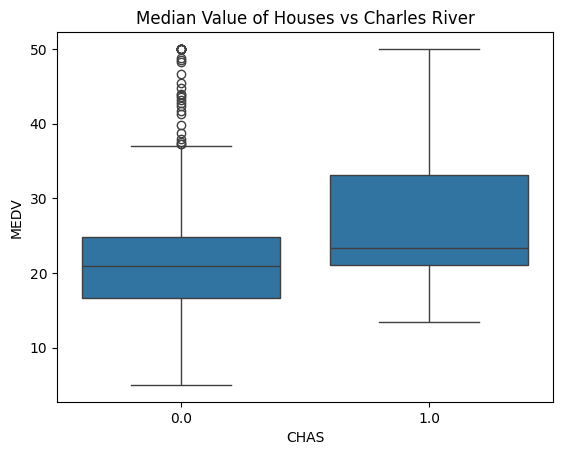

In [6]:
sns.boxplot(x="CHAS", y="MEDV", data=boston_df)
pyplot.title("Median Value of Houses vs Charles River")
pyplot.show()

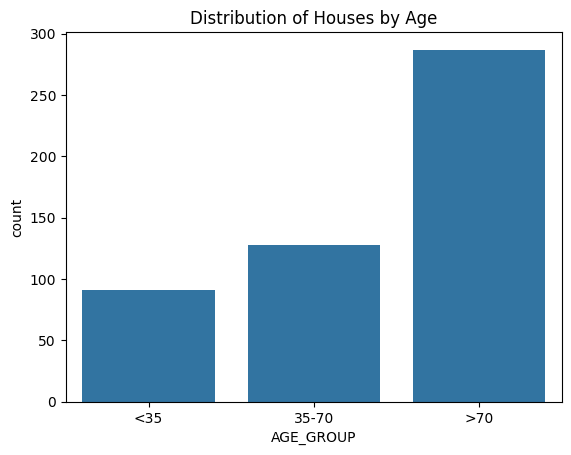

In [7]:
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'],
                               bins=[0,35,70,100],
                               labels=['<35','35-70','>70'])

sns.countplot(x="AGE_GROUP", data=boston_df)
pyplot.title("Distribution of Houses by Age")
pyplot.show()

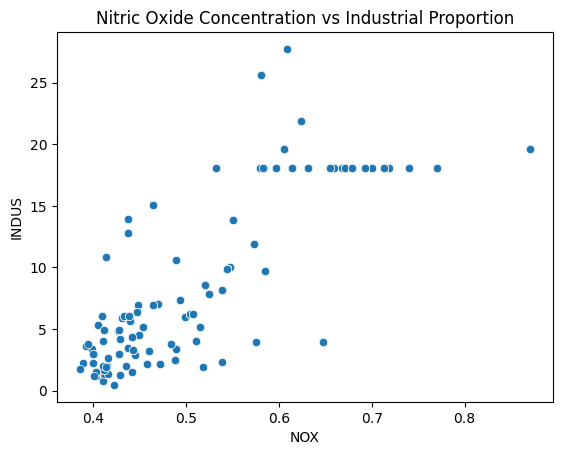

In [9]:
sns.scatterplot(x="NOX", y="INDUS", data=boston_df)
pyplot.title("Nitric Oxide Concentration vs Industrial Proportion")
pyplot.show()

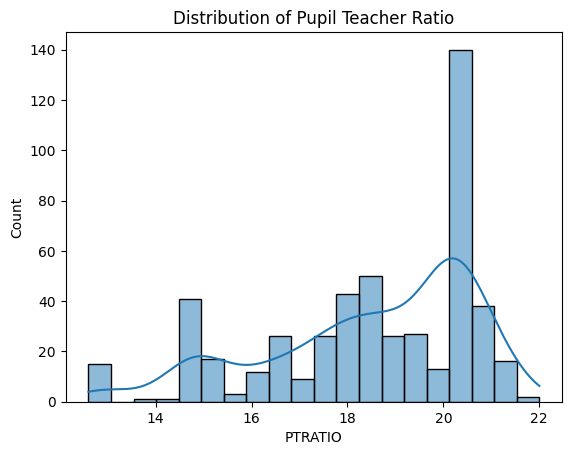

In [11]:
sns.histplot(boston_df['PTRATIO'], bins=20, kde=True)
pyplot.title("Distribution of Pupil Teacher Ratio")
pyplot.show()

In [12]:
river = boston_df[boston_df['CHAS'] == 1]['MEDV']
not_river = boston_df[boston_df['CHAS'] == 0]['MEDV']

scipy.stats.ttest_ind(river, not_river)

TtestResult(statistic=3.996437466090509, pvalue=7.390623170519905e-05, df=504.0)

In [13]:
river = boston_df[boston_df['CHAS'] == 1]['MEDV']
not_river = boston_df[boston_df['CHAS'] == 0]['MEDV']

scipy.stats.ttest_ind(river, not_river)

TtestResult(statistic=3.996437466090509, pvalue=7.390623170519905e-05, df=504.0)

In [14]:
young = boston_df[boston_df['AGE_GROUP']=='<35']['MEDV']
middle = boston_df[boston_df['AGE_GROUP']=='35-70']['MEDV']
old = boston_df[boston_df['AGE_GROUP']=='>70']['MEDV']

scipy.stats.f_oneway(young, middle, old)

F_onewayResult(statistic=36.40764999196599, pvalue=1.7105011022702984e-15)

In [15]:
scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

PearsonRResult(statistic=0.7636514469209192, pvalue=7.913361061210442e-98)

In [16]:
model = ols('MEDV ~ DIS', data=boston_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           1.21e-08
Time:                        16:52:01   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.3901      0.817     22.499      0.0

Regression Analysis: MEDV vs DIS

A simple linear regression analysis was conducted to examine the relationship between the distance to employment centers (DIS) and the median value of owner-occupied homes (MEDV).

The regression model indicates that there is a relationship between the distance from employment centers and housing prices in Boston.

The regression coefficient for DIS represents the expected change in the median home value for each one-unit increase in distance to employment centers. If the coefficient is positive, it suggests that homes located farther from employment centers tend to have higher median values. Conversely, a negative coefficient would indicate that housing prices decrease as the distance increases.

The p-value associated with the DIS coefficient determines whether this relationship is statistically significant. If the p-value is less than the significance level (commonly 0.05), we reject the null hypothesis and conclude that distance to employment centers has a statistically significant effect on housing prices.

The R-squared value explains how much variation in housing prices can be explained by the distance variable. A higher R-squared value indicates that the model explains a larger proportion of the variation in housing prices.

In conclusion, the regression analysis helps determine whether the distance to employment centers is a significant predictor of housing prices in Boston.

Nếu muốn được điểm peer review cao hơn, bạn có thể viết bản ngắn nhưng chuẩn hơn (giảng viên thích):

Short Conclusion

The regression results show that the variable DIS (distance to employment centers) has a statistically significant relationship with MEDV (median house value) when the p-value is below 0.05. This indicates that distance to employment centers can be used as a predictor of housing prices. However, the strength of this relationship depends on the R-squared value, which shows how much of the variation in house prices is explained by the model.